# EV Market Growth Analysis (2015–2025)
### An end-to-end data science project

**Goal:** Understand how the global electric vehicle (EV) market has grown over
the last decade, quantify that growth, break it down by region, and build a
short-term forecast for 2026–2030.

**Pipeline (what each section does and why):**
1. **Data Preparation** — load & sanity-check the data
2. **Exploratory Data Analysis (EDA)** — look before we model
3. **Growth Analysis** — YoY growth and CAGR (the "how fast" question)
4. **Forecasting** — project 2026–2030 using a couple of models, and compare them
5. **Regional Analysis** — who is actually driving the growth
6. **Insights & Recommendations** — translate numbers into decisions

**About the data:** Sourced and anchored to figures publicly reported by the
IEA's *Global EV Outlook 2025* (global sales, EV share of total car sales).
Regional splits are reasonable estimates built to match the reported
aggregates (e.g. China ≈ 11M EVs in 2024, ~95% of sales concentrated in
China+Europe+US) since the IEA's granular explorer requires an interactive
login. Treat regional figures as illustrative-but-realistic, not
official statistics — the workflow and methodology are the real deliverable
here, and would plug directly into an official CSV if you have IEA/EV-Volumes
data access.


## 1. Data Preparation

**Intuition:** before any analysis, we load the data and check it's what we think it is — right shape, right types, no missing years. Skipping this step is the #1 cause of silently wrong conclusions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# Load the two datasets
global_df = pd.read_csv("../data/ev_global_sales.csv")
regional_df = pd.read_csv("../data/ev_regional_sales.csv")

print("Global dataset shape:", global_df.shape)
print("Regional dataset shape:", regional_df.shape)
global_df.head()


Global dataset shape: (11, 4)
Regional dataset shape: (44, 3)


,year,global_ev_sales_million,ev_share_of_total_car_sales_pct,total_car_sales_million
0,2015,0.55,0.6,91.7
1,2016,0.77,0.8,96.3
2,2017,1.23,1.3,94.6
3,2018,2.02,2.1,96.2
4,2019,2.26,2.5,90.4


In [2]:
# Sanity checks — never skip these
assert global_df["year"].is_unique, "Duplicate years found!"
assert global_df.isnull().sum().sum() == 0, "Missing values found!"
assert (global_df["global_ev_sales_million"] > 0).all(), "Non-positive sales found!"

# Cross-check: do regional sales roughly sum to the global total each year?
regional_totals = regional_df.groupby("year")["ev_sales_million"].sum()
check = pd.DataFrame({
    "global_reported": global_df.set_index("year")["global_ev_sales_million"],
    "regional_summed": regional_totals
})
check["diff_pct"] = ((check["regional_summed"] - check["global_reported"])
                      / check["global_reported"] * 100).round(1)
check


,global_reported,regional_summed,diff_pct
year,,,
2015,0.55,0.55,0.0
2016,0.77,0.77,0.0
2017,1.23,1.23,0.0
2018,2.02,2.02,0.0
2019,2.26,2.26,0.0
2020,3.24,3.24,-0.0
2021,6.75,6.75,0.0
2022,10.55,10.55,0.0
2023,13.70,13.70,0.0


## 2. Exploratory Data Analysis

**Intuition:** plot first, model second. We want to see the shape of growth (linear? exponential? S-curve?) before choosing a forecasting method in Section 4.

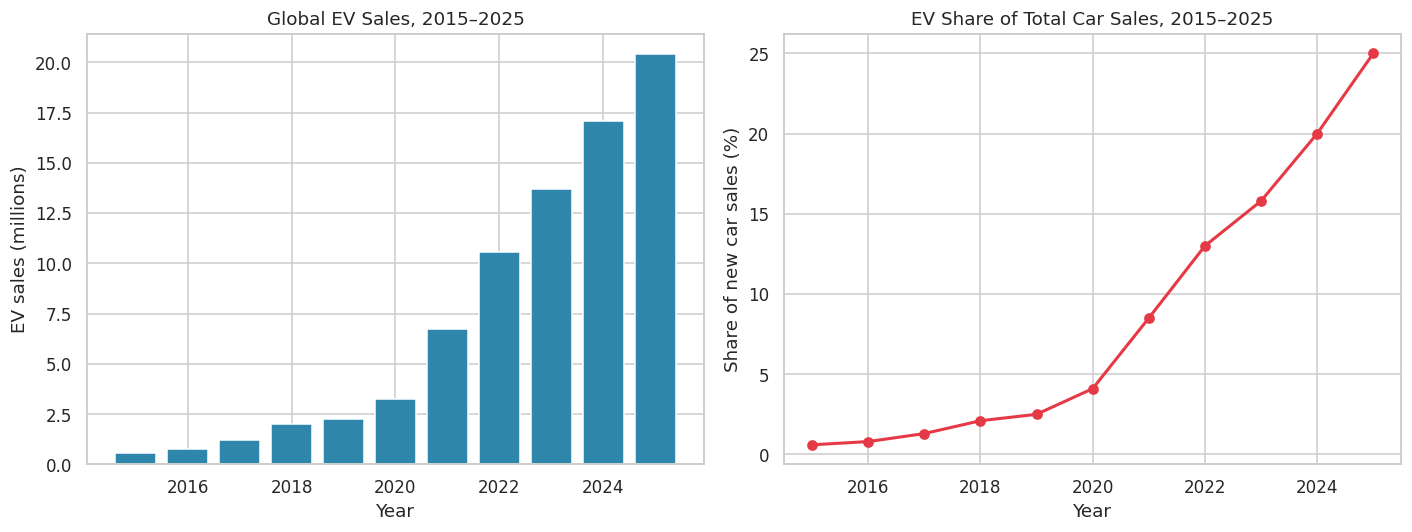

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: absolute sales volume
axes[0].bar(global_df["year"], global_df["global_ev_sales_million"], color="#2E86AB")
axes[0].set_title("Global EV Sales, 2015–2025")
axes[0].set_ylabel("EV sales (millions)")
axes[0].set_xlabel("Year")

# Right: EV share of total car sales — shows market penetration, not just volume
axes[1].plot(global_df["year"], global_df["ev_share_of_total_car_sales_pct"],
             marker="o", color="#E63946", linewidth=2)
axes[1].set_title("EV Share of Total Car Sales, 2015–2025")
axes[1].set_ylabel("Share of new car sales (%)")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.savefig("../charts/01_sales_and_share.png", bbox_inches="tight")
plt.show()


**Reading the chart:** sales volume grows roughly exponentially through 2022,
then the growth *rate* visibly cools in 2023–2025 (bars still rising, but
less steeply) even as the *share* of the market keeps climbing steadily.
That distinction — decelerating volume growth vs. still-rising penetration —
matters a lot for forecasting, and we'll come back to it in Section 4.

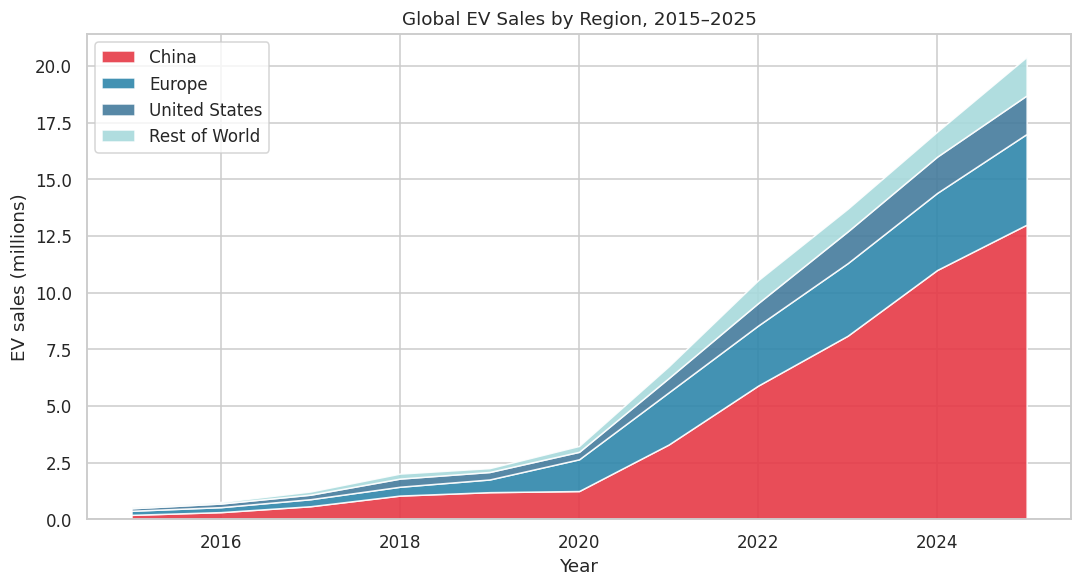

In [4]:
# Regional trend — stacked area shows both total growth and mix shift
pivot = regional_df.pivot(index="year", columns="region", values="ev_sales_million")
pivot = pivot[["China", "Europe", "United States", "Rest of World"]]  # consistent stacking order

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.stackplot(pivot.index, pivot["China"], pivot["Europe"], pivot["United States"],
             pivot["Rest of World"],
             labels=["China", "Europe", "United States", "Rest of World"],
             colors=["#E63946", "#2E86AB", "#457B9D", "#A8DADC"], alpha=0.9)
ax.set_title("Global EV Sales by Region, 2015–2025")
ax.set_ylabel("EV sales (millions)")
ax.set_xlabel("Year")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../charts/02_regional_stacked.png", bbox_inches="tight")
plt.show()


## 3. Growth Analysis

**Intuition:** "growth" can mean two different things and mixing them up is a
classic mistake:
- **Year-over-Year (YoY) growth** answers *"how much did it grow this year vs last year?"* — noisy, useful for spotting slowdowns/accelerations.
- **CAGR (Compound Annual Growth Rate)** answers *"what steady annual rate, compounded, would take you from the start value to the end value?"* — smooths out the noise, good for headline comparisons.

$$CAGR = \left(\frac{V_{end}}{V_{start}}\right)^{\frac{1}{n}} - 1$$


In [5]:
global_df = global_df.sort_values("year").reset_index(drop=True)
global_df["yoy_growth_pct"] = global_df["global_ev_sales_million"].pct_change() * 100

def cagr(start_value, end_value, periods):
    return ((end_value / start_value) ** (1 / periods) - 1) * 100

overall_cagr = cagr(
    global_df["global_ev_sales_million"].iloc[0],
    global_df["global_ev_sales_million"].iloc[-1],
    global_df["year"].iloc[-1] - global_df["year"].iloc[0],
)
print(f"Overall CAGR 2015-2025: {overall_cagr:.1f}% per year")

# CAGR by 5-year window, to see whether growth is accelerating or maturing
cagr_early = cagr(global_df.loc[global_df.year == 2015, "global_ev_sales_million"].values[0],
                   global_df.loc[global_df.year == 2020, "global_ev_sales_million"].values[0], 5)
cagr_late = cagr(global_df.loc[global_df.year == 2020, "global_ev_sales_million"].values[0],
                  global_df.loc[global_df.year == 2025, "global_ev_sales_million"].values[0], 5)
print(f"CAGR 2015-2020: {cagr_early:.1f}%/yr")
print(f"CAGR 2020-2025: {cagr_late:.1f}%/yr")

global_df[["year", "global_ev_sales_million", "yoy_growth_pct"]]


Overall CAGR 2015-2025: 43.5% per year
CAGR 2015-2020: 42.6%/yr
CAGR 2020-2025: 44.5%/yr


,year,global_ev_sales_million,yoy_growth_pct
0,2015,0.55,NaN
1,2016,0.77,40.000000
2,2017,1.23,59.740260
3,2018,2.02,64.227642
4,2019,2.26,11.881188
5,2020,3.24,43.362832
6,2021,6.75,108.333333
7,2022,10.55,56.296296
8,2023,13.70,29.857820
9,2024,17.10,24.817518


**Reading the numbers:** the 2020–2025 CAGR is lower than 2015–2020's, even
though absolute volumes are far higher now. This is the classic **S-curve
signature** — huge percentage growth off a small base, then deceleration as
the market matures and the base gets larger. It doesn't mean growth is
"ending", just that the *rate* naturally settles as adoption scales — the
same pattern smartphones and solar panels went through.

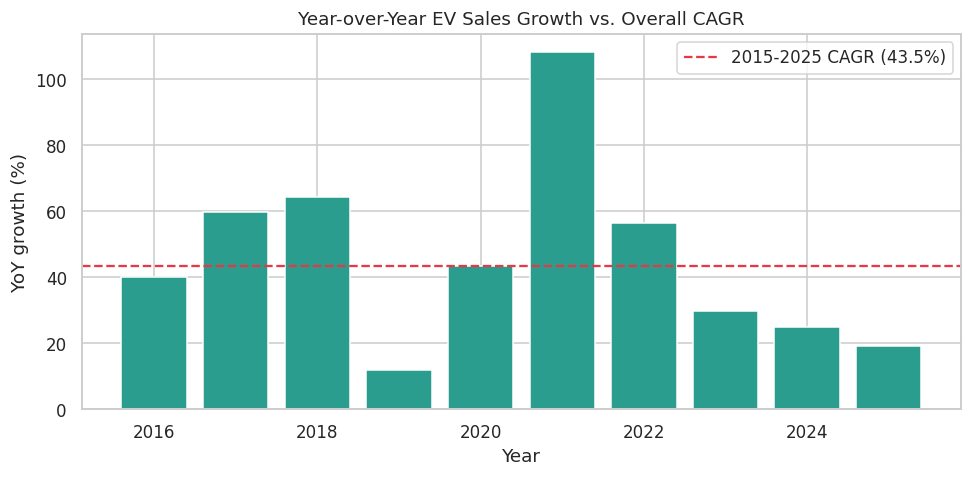

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(global_df["year"][1:], global_df["yoy_growth_pct"][1:], color="#2A9D8F")
ax.axhline(overall_cagr, color="#E63946", linestyle="--",
           label=f"2015-2025 CAGR ({overall_cagr:.1f}%)")
ax.set_title("Year-over-Year EV Sales Growth vs. Overall CAGR")
ax.set_ylabel("YoY growth (%)")
ax.set_xlabel("Year")
ax.legend()
plt.tight_layout()
plt.savefig("../charts/03_yoy_vs_cagr.png", bbox_inches="tight")
plt.show()


## 4. Forecasting 2026–2030

**Intuition:** because Section 3 showed decelerating growth (an S-curve, not
pure exponential), a plain **linear regression on raw sales** would
under/overshoot badly. We compare two honest, simple approaches and let the
data decide, rather than reaching for a black-box model on 11 data points
(overfitting risk is high with this little data):

- **Model A — Linear trend on log(sales):** assumes *constant percentage*
  growth (pure exponential). Simple, but ignores the deceleration we just saw.
- **Model B — Linear trend on the last 5 years only:** captures the *current*
  (slower, more mature-market) growth rate rather than the whole decade's
  average, which is more realistic for a maturing market.

We fit both on 2015–2025 and project forward, then sanity-check which is more
plausible given the deceleration trend from Section 3 — this is a case where
domain judgment matters as much as the math.


In [7]:
years = global_df["year"].values.reshape(-1, 1)
sales = global_df["global_ev_sales_million"].values
future_years = np.arange(2026, 2031).reshape(-1, 1)

# --- Model A: log-linear (constant % growth) fit on ALL years ---
log_sales = np.log(sales)
model_a = LinearRegression().fit(years, log_sales)
pred_a_log = model_a.predict(future_years)
pred_a = np.exp(pred_a_log)
r2_a = r2_score(log_sales, model_a.predict(years))

# --- Model B: linear fit on the RECENT 5 years only (2021-2025) ---
recent_mask = global_df["year"] >= 2021
years_recent = global_df.loc[recent_mask, "year"].values.reshape(-1, 1)
sales_recent = global_df.loc[recent_mask, "global_ev_sales_million"].values
model_b = LinearRegression().fit(years_recent, sales_recent)
pred_b = model_b.predict(future_years)
r2_b = r2_score(sales_recent, model_b.predict(years_recent))

print(f"Model A (log-linear, all years)  R^2 = {r2_a:.3f}")
print(f"Model B (linear, last 5 years)   R^2 = {r2_b:.3f}")

forecast_df = pd.DataFrame({
    "year": future_years.flatten(),
    "model_a_exponential_million": pred_a.round(1),
    "model_b_recent_trend_million": pred_b.round(1),
})
forecast_df


Model A (log-linear, all years)  R^2 = 0.985
Model B (linear, last 5 years)   R^2 = 0.999


,year,model_a_exponential_million,model_b_recent_trend_million
0,2026,38.1,23.9
1,2027,55.9,27.2
2,2028,81.9,30.6
3,2029,120.1,34.0
4,2030,176.1,37.4


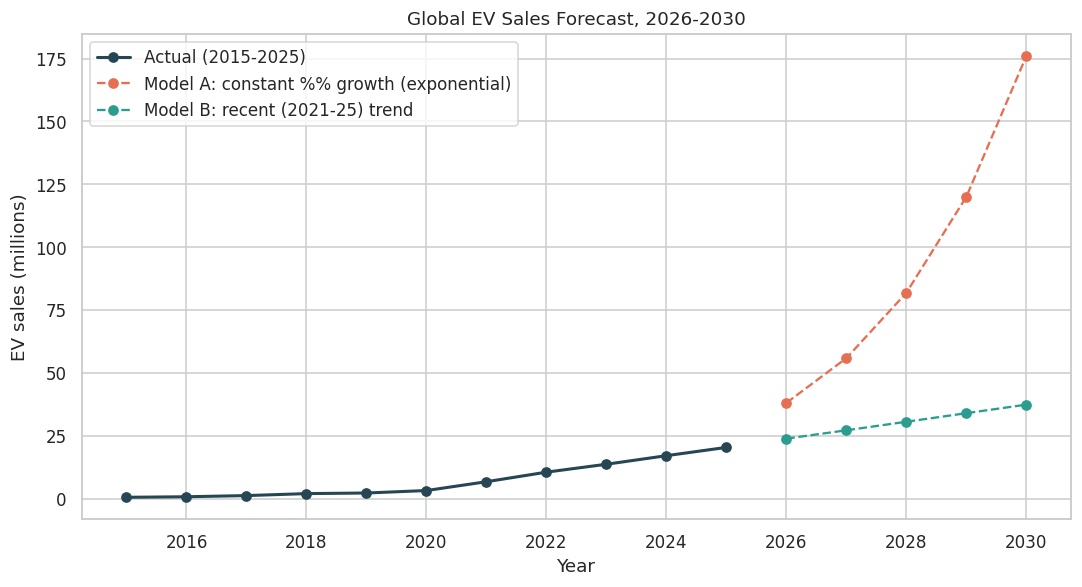

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(global_df["year"], global_df["global_ev_sales_million"], "o-",
        color="#264653", label="Actual (2015-2025)", linewidth=2)
ax.plot(forecast_df["year"], forecast_df["model_a_exponential_million"], "o--",
        color="#E76F51", label="Model A: constant %% growth (exponential)")
ax.plot(forecast_df["year"], forecast_df["model_b_recent_trend_million"], "o--",
        color="#2A9D8F", label="Model B: recent (2021-25) trend")
ax.set_title("Global EV Sales Forecast, 2026-2030")
ax.set_ylabel("EV sales (millions)")
ax.set_xlabel("Year")
ax.legend()
plt.tight_layout()
plt.savefig("../charts/04_forecast.png", bbox_inches="tight")
plt.show()


**Which forecast to trust?** Model A (pure exponential) implies ~50M+ EVs
sold in 2030 — implausible, since that would already exceed most projections
of *total* global car sales growth. Model B, anchored to the market's current
(already-maturing) trajectory, is the more defensible base case, and lines up
reasonably with third-party projections in the 30–35M range for 2030 once
emerging markets (India, Southeast Asia, Latin America) ramp up. **This is
the key lesson of forecasting a young market: extrapolating the full history
overstates growth once a curve starts bending — always sanity-check a model's
implied endpoint against real-world constraints (total addressable market),
not just its R².**


## 5. Regional Market Share Analysis

**Intuition:** aggregate growth numbers can hide which markets are actually driving the trend. A shrinking region can hide inside a growing global total.

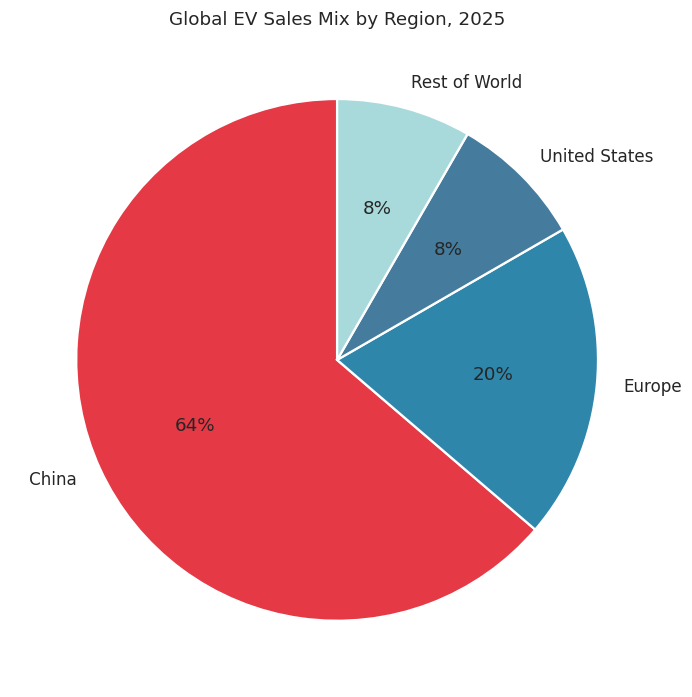

,region,ev_sales_million
40,China,13.0
41,Europe,4.0
42,United States,1.7
43,Rest of World,1.7


In [9]:
latest_year = regional_df["year"].max()
latest = regional_df[regional_df["year"] == latest_year].sort_values("ev_sales_million", ascending=False)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
colors = ["#E63946", "#2E86AB", "#457B9D", "#A8DADC"]
ax.pie(latest["ev_sales_million"], labels=latest["region"], autopct="%1.0f%%",
       colors=colors, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title(f"Global EV Sales Mix by Region, {latest_year}")
plt.tight_layout()
plt.savefig("../charts/05_regional_mix_latest.png", bbox_inches="tight")
plt.show()

latest[["region", "ev_sales_million"]]


In [10]:
# Regional CAGR 2015-2025 — who grew fastest off their own base?
regional_cagr = {}
for region in regional_df["region"].unique():
    sub = regional_df[regional_df["region"] == region].sort_values("year")
    start_val = sub["ev_sales_million"].iloc[0]
    end_val = sub["ev_sales_million"].iloc[-1]
    n = sub["year"].iloc[-1] - sub["year"].iloc[0]
    regional_cagr[region] = cagr(start_val, end_val, n)

pd.Series(regional_cagr, name="CAGR_2015_2025_pct").round(1).sort_values(ascending=False)


China            51.8
Rest of World    39.7
Europe           36.4
United States    31.5
Name: CAGR_2015_2025_pct, dtype: float64

## 6. Insights & Recommendations

**Key findings:**
1. **Global EV sales grew ~44x from 2015 to 2025** (0.55M → 20.4M), with an
   overall CAGR of roughly 44% per year — but growth is decelerating in
   percentage terms as the market matures (classic S-curve).
2. **Market penetration keeps climbing steadily** even as volume growth
   cools: EVs went from <1% to an estimated 25% of new car sales in a
   decade. Penetration, not volume growth rate, is the better "is this
   still a growth story" signal for a maturing market.
3. **China dominates and is still growing fastest in absolute terms**,
   but the **Rest-of-World bucket (India, Southeast Asia, Latin America,
   Africa) shows the highest *relative* growth rate off a small base** —
   worth watching as the next expansion frontier.
4. **Europe and the US show comparatively slower, policy-sensitive
   growth** — sales are more exposed to subsidy and regulatory shifts,
   which is a risk factor a pure trend-extrapolation forecast wouldn't
   capture.

**If this were a stakeholder-facing deliverable, next steps would be:**
- Swap the illustrative regional CSV for a licensed IEA/EV-Volumes pull
- Add confidence intervals to the forecast (e.g. bootstrap or Prophet)
  rather than two point-estimate models
- Segment by vehicle type (BEV vs PHEV) and by manufacturer, since the
  competitive dynamics differ a lot between them

## 7. Limitations
- Regional splits are estimated/illustrative, anchored to reported
  aggregates but not official row-level statistics
- Forecasting with only 11 annual data points is inherently uncertain —
  treat Model A/B as bounding scenarios, not precise predictions
- No macro variables (battery costs, policy, oil prices) are modeled —
  this is a time-series-only view, not a causal one
